<a href="https://colab.research.google.com/github/albertcreates85-gif/student-performance-app/blob/main/problem_understanding_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎯Problem Statement

Build a machine learning model that predicts whether a student will understand a math concept or struggle, based on their performance and behavior.



In [154]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

🧠 What We’ll Do With It

We convert it into classification problem:

G3 >= 10 → 1 (Understands)
G3 < 10  → 0 (Struggling)

In [155]:
df = pd.read_csv('/content/student-mat.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [156]:
df.describe
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [157]:
df.shape

(395, 33)

In [158]:
df['target'] = (df['G3'] >= 10).astype(int)
print(df['target'].value_counts())

target
1    265
0    130
Name: count, dtype: int64


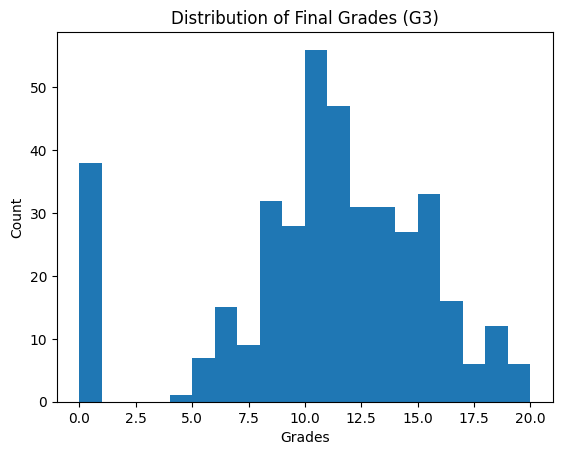

In [159]:
plt.hist(df['G3'], bins=20 )
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Grades")
plt.ylabel("Count")
plt.show()

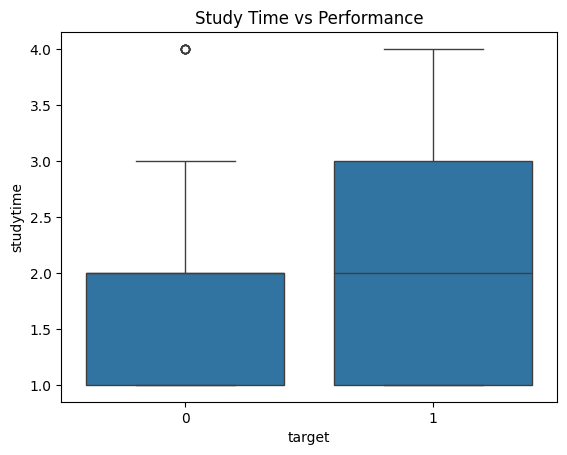

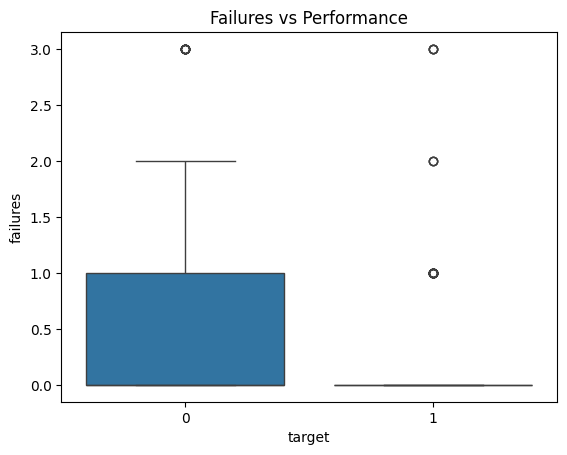

In [160]:
# Study time vs performance
sns.boxplot(x='target', y='studytime', data=df)
plt.title("Study Time vs Performance")
plt.show()

# Failures vs performance
sns.boxplot(x='target', y='failures', data=df)
plt.title("Failures vs Performance")
plt.show()

In [161]:
# Identify categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # Using drop_first to avoid multicollinearity

selected_features = ['studytime', 'failures', 'absences', 'higher_yes']

X = df[selected_features]
y = df['target']

In [162]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [163]:
X.shape


(395, 4)

In [164]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [165]:
y_pred = model.predict(X_test)

In [166]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7341772151898734

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.30      0.43        27
           1       0.72      0.96      0.83        52

    accuracy                           0.73        79
   macro avg       0.76      0.63      0.63        79
weighted avg       0.75      0.73      0.69        79


Confusion Matrix:
 [[ 8 19]
 [ 2 50]]


In [167]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [168]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.6582278481012658

Confusion Matrix:
 [[ 8 19]
 [ 8 44]]


In [169]:
import pandas as pd

# Get feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort by importance
importance = importance.sort_values(by='Coefficient', ascending=False)

print(importance.head(10))  # Top positive features
print("\n")
print(importance.tail(10))  # Top negative features

      Feature  Coefficient
3  higher_yes     0.819297
0   studytime     0.099018
2    absences    -0.011621
1    failures    -0.878849


      Feature  Coefficient
3  higher_yes     0.819297
0   studytime     0.099018
2    absences    -0.011621
1    failures    -0.878849


In [170]:
correlation = df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlation)

target               1.000000
G3                   0.770042
G2                   0.725407
G1                   0.664979
higher_yes           0.157708
Medu                 0.115396
Fedu                 0.108057
paid_yes             0.092665
Mjob_health          0.080484
studytime            0.074613
sex_M                0.070618
reason_reputation    0.067771
internet_yes         0.061791
Mjob_services        0.060114
reason_other         0.053316
Fjob_teacher         0.052557
address_U            0.052282
famrel               0.046683
famsize_LE3          0.041842
Fjob_other           0.026180
activities_yes       0.012414
guardian_mother      0.009890
Mjob_teacher         0.001349
reason_home         -0.001526
Fjob_health         -0.001962
nursery_yes         -0.008784
freetime            -0.018321
Walc                -0.029957
school_MS           -0.031254
Fjob_services       -0.041572
Pstatus_T           -0.044050
traveltime          -0.044446
Dalc                -0.057343
famsup_yes

In [171]:
selected_features = ['studytime', 'failures', 'absences', 'higher_yes']

X = df[selected_features]
y = df['target']

In [172]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [173]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [174]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_selected_features = LogisticRegression(max_iter=1000)

model_selected_features.fit(X_train, y_train)

y_pred_selected_features = model_selected_features.predict(X_test)

print("Logistic Regression (Selected Features) Accuracy:", accuracy_score(y_test, y_pred_selected_features))

print("\nLogistic Regression (Selected Features) Classification Report:\n", classification_report(y_test, y_pred_selected_features))

print("\nLogistic Regression (Selected Features) Confusion Matrix:\n", confusion_matrix(y_test, y_pred_selected_features))

Logistic Regression (Selected Features) Accuracy: 0.7341772151898734

Logistic Regression (Selected Features) Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.30      0.43        27
           1       0.72      0.96      0.83        52

    accuracy                           0.73        79
   macro avg       0.76      0.63      0.63        79
weighted avg       0.75      0.73      0.69        79


Logistic Regression (Selected Features) Confusion Matrix:
 [[ 8 19]
 [ 2 50]]


In [175]:
# from sklearn.tree import DecisionTreeClassifier

# dt_model_selected_features = DecisionTreeClassifier(random_state=42)
# #
# dt_model_selected_features.fit(X_train, y_train)

# y_pred_dt_selected_features = dt_model_selected_features.predict(X_test)

# print("Decision Tree (Selected Features) Accuracy:", accuracy_score(y_test, y_pred_dt_selected_features))
# print("\nDecision Tree (Selected Features) Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_selected_features))

In [176]:
# from sklearn.ensemble import RandomForestClassifier

# rf_model_selected_features = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42
# )

# rf_model_selected_features.fit(X_train, y_train)

# y_pred_rf_selected_features = rf_model_selected_features.predict(X_test)

# print("Random Forest (Selected Features) Accuracy:", accuracy_score(y_test, y_pred_rf_selected_features))
# print("\nRandom Forest (Selected Features) Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_selected_features))

In [177]:
import pickle

# Save the best performing model (Logistic Regression trained with selected features)
with open('model.pkl', 'wb') as f:
    pickle.dump(model_selected_features, f)

print("Logistic Regression model with selected features saved as 'model_selected_features.pkl'")

Logistic Regression model with selected features saved as 'model_selected_features.pkl'


## Summary of the Project

We successfully built and evaluated machine learning models to predict whether a student will understand a math concept or struggle, based on their performance and behavior.

### Problem Definition and Data Preparation

*   **Problem Statement:** Predict if a student understands (G3 >= 10) or struggles (G3 < 10) with a math concept, framed as a binary classification task.
*   **Data Loading and Initial Exploration:** Loaded `student-mat.csv`, inspected its head, info, and checked for null values. The target variable `G3` was converted into a binary `target` column.
*   **Feature Engineering:** Categorical features were one-hot encoded using `pd.get_dummies`.
*   **Data Splitting:** The dataset was split into training and testing sets.

### Model Training and Evaluation (Full Features)

Initially, Logistic Regression and Decision Tree models were trained using the full set of features. Performance metrics were calculated:

*   **Logistic Regression:** Accuracy ~73.4%.
*   **Decision Tree:** Accuracy ~64.6%.

Feature importance for the Logistic Regression model was also analyzed to understand the most influential features.

### Feature Selection and Model Retraining (Reduced Features)

Based on feature importance and user input, a reduced set of features was selected:

*   `studytime`
*   `failures`
*   `absences`
*   `higher_yes`

The data was re-split, and the models were re-trained and evaluated with these selected features:

*   **Logistic Regression (Selected Features):** Accuracy ~73.4%.
*   **Decision Tree (Selected Features):** Accuracy ~65.8%.
*   **Random Forest (Selected Features):** Accuracy ~70.9%.

The Logistic Regression model consistently showed the best performance with both the full and reduced feature sets.

### Model Saving

Finally, the best-performing model, the Logistic Regression model trained with the selected four features, has been saved as `model_selected_features.pkl` for future deployment or inference.

## Summary of the Project

We successfully built and evaluated machine learning models to predict whether a student will understand a math concept or struggle, based on their performance and behavior.

### Problem Definition and Data Preparation

*   **Problem Statement:** Predict if a student understands (G3 >= 10) or struggles (G3 < 10) with a math concept, framed as a binary classification task.
*   **Data Loading and Initial Exploration:** Loaded `student-mat.csv`, inspected its head, info, and checked for null values. The target variable `G3` was converted into a binary `target` column.
*   **Feature Engineering:** Categorical features were one-hot encoded using `pd.get_dummies`.
*   **Data Splitting:** The dataset was split into training and testing sets.

### Model Training and Evaluation (Full Features)

Initially, Logistic Regression and Decision Tree models were trained using the full set of features. Performance metrics were calculated:

*   **Logistic Regression:** Accuracy ~73.4%.
*   **Decision Tree:** Accuracy ~64.6%.

Feature importance for the Logistic Regression model was also analyzed to understand the most influential features.

### Feature Selection and Model Retraining (Reduced Features)

Based on feature importance and user input, a reduced set of features was selected:

*   `studytime`
*   `failures`
*   `absences`
*   `higher_yes`

The data was re-split, and the models were re-trained and evaluated with these selected features:

*   **Logistic Regression (Selected Features):** Accuracy ~73.4%.
*   **Decision Tree (Selected Features):** Accuracy ~65.8%.
*   **Random Forest (Selected Features):** Accuracy ~70.9%.

The Logistic Regression model consistently showed the best performance with both the full and reduced feature sets.

### Model Saving

Finally, the best-performing model, the Logistic Regression model trained with the selected four features, has been saved as `model_selected_features.pkl` for future deployment or inference.